In [ ]:
from google.colab import files
data = files.upload()

Saving Final_Data.xlsx to Final_Data.xlsx


1. Data Loading and Overview:

We begin by loading the dataset, named "Final_Data.csv," into a Pandas DataFrame. We display the first few rows of the DataFrame to provide an initial overview of the data's structure and content.

2. Getting a Summary of the Dataset:

To ensure data integrity, we perform a thorough data quality check. We examine data types to confirm that each column is assigned the appropriate data type (e.g., numeric, string, date).

3. Descriptive Statistics:

In this step, To gain insights into the dataset's numerical features, we calculate summary statistics for numeric columns.

4. Count Number of Unique Values:

Understanding the diversity and uniqueness of categorical variables is essential for event planning and engagement strategies. Analyze the results to understand the variety of responses and preferences among residents.

5. Checking for Unique Values:

Identify the unique set of variables in the dataframe inorder to identify the unique values if any kind of discrepancy present in the data.

6. Checking for Missing Values:

Identify and report missing values in the dataset, which may require data imputation or further data collection strategies.

7. Check for Duplicate Values:

One important aspect of data quality is identifying and handling duplicated data. We utilise the duplicated() method in pandas to check for duplicated rows within the dataset. The sum() function is then applied to count the total number of duplicated rows. Duplicated data can introduce bias and inaccuracies into our analysis, so it's

essential to address it appropriately

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns



df = pd.read_excel('Final_Data.xlsx')



# Display the first few rows of the DataFrame to get an overview of the data

print("First few rows of the DataFrame:")

print(df.head())



# Check the data types and missing values in each column

print("\nData types and missing values:")

print(df.info())



# Get summary statistics for numeric columns

print("\nSummary statistics for numeric columns:")

print(df.describe())



# Count the number of unique values in each column

print("\nNumber of unique values in each column:")

print(df.nunique())



# Check the unique values in each column

for i in df.columns:



    print(f"\nCheck unique values in {i} column:")

    print(df[i].unique())



# Check for missing values in the DataFrame

print("\nMissing values count in each column:")

print(df.isnull().sum())



# Check for Duplicate values in the DataFrame

print("\Duplicate values count in the Dataframe:")

print(df.duplicated().sum())



First few rows of the DataFrame:
   Unnamed: 0  Flat no Wing Owner Name Owner's Spouse Name No of Resident  \
0           0      101    A      Omkar                   -              4   
1           1      102    A    Bhavana                   -              5   
2           2      103    A     Govind                   -              5   
3           3      201    A      Reena                   -              4   
4           4      202    A   Karishma                   -              7   

  Confirmed Members Origin of Owner  Flat Area (sq.mt)  No of Room  \
0                 4     Maharashtra                500           2   
1                 6       Bangalore                500           2   
2                 3       Rajasthan                500           2   
3                 2  Madhya Pradesh                550           2   
4                15         Gujurat                600           3   

  Tenant or owner Maintenance Amt Availlability of owner Flat Vacancy  \
0         

1. Replace "_" with NaN in the entire DataFrame

We begin by addressing missing data. In our dataset, missing values are represented as underscores. We'll replace these underscores with NaN (Not-a-Number) values using the replace function to facilitate further data processing.

2. Handling Missing Values:

We identify and remove two columns, 'Unnamed: 0' and 'Owner's Spouse Name,' as they are not relevant to our analysis. Dropping unnecessary columns helps simplify the dataset.

3. Data Type Conversion:

We ensure that relevant columns are of the correct data types for analysis. Specifically, we convert 'No of Resident' and 'Confirmed Members' columns to numeric data types while handling any conversion errors by setting them to NaN.

4. Impute Missing Values in 'Maintenance Amt' , ‘Flat Vacancy’, 'Donation', ‘No of Resident' , 'Confirmed Members', 'Availability of owner' and 'Origin of Owner'

To address missing values in the 'Maintenance Amt' column, we iteratively go through the DataFrame. For each missing value, we impute it based on the corresponding 'Flat Area (sq.mt)' value. We reference a previously calculated dictionary, 'avg_maintenance_amt,' to fill in these values
We handle missing values in the 'Flat Vacancy' column by using a conditional approach. If 'Availability of owner' is 'Yes,' we assume the flat is owned ('Flat Vacancy' is 'Owned'), and if 'Availability of owner' is not 'Yes,' we consider the flat as vacant ('Flat Vacancy' is 'Vacant').
For missing values in the 'Donation', ‘No of Resident' , 'Confirmed Members' column, we impute them with the median value of the respective column.
Finally, we handle missing values in the 'Availability of owner' and 'Origin of Owner' columns by imputing them with the mode (most frequent value) of their respective columns.

In [ ]:
df.replace("-",np.nan,inplace = True)

In [ ]:
print(df.isnull().sum()/df.shape[0]*100)

Unnamed: 0                 0.000000
Flat no                    0.000000
Wing                       0.000000
Owner Name                 0.000000
Owner's Spouse Name       81.666667
No of Resident             6.666667
Confirmed Members          6.666667
Origin of Owner            1.666667
Flat Area (sq.mt)          0.000000
No of Room                 0.000000
Tenant or owner            0.000000
Maintenance Amt           48.333333
Availlability of owner     1.666667
Flat Vacancy              30.000000
Donation                   8.333333
dtype: float64


In [ ]:
df.drop(['Unnamed: 0','Owner\'s Spouse Name'],axis =1, inplace =True)

In [ ]:
# Convert "No of Resident" and "Confirmed Members" to numeric (assuming they should be numeric)
df['No of Resident'] = pd.to_numeric(df['No of Resident'], errors='coerce')

In [ ]:
df['Confirmed Members'] = pd.to_numeric(df['Confirmed Members'],errors = 'coerce')

In [ ]:
df['Maintenance Amt'] = pd.to_numeric(df['Maintenance Amt'],errors= 'coerce')

In [ ]:
avg_maintenance_amt = df.groupby('Flat Area (sq.mt)')['Maintenance Amt'].mean()
avg_maintenance_amt

Flat Area (sq.mt)
500    5875.0
550    6000.0
600    7000.0
Name: Maintenance Amt, dtype: float64

In [ ]:
for index,row in df.iterrows():
  if pd.isnull(row['Maintenance Amt']):
    flat_area = row['Flat Area (sq.mt)']
    if flat_area in avg_maintenance_amt:
      df.at[index, 'Maintenance Amt'] = avg_maintenance_amt[flat_area]



In [ ]:
# Impute missing values in 'Flat Vacancy' column with the median

df['Flat Vacancy'].fillna(df.apply(lambda row: 'Owned' if row['Availlability of owner'] == 'Yes' else 'Vacant', axis=1), inplace=True)

# Impute missing values in 'Donation' column with the median

df['Donation'].fillna(df['Donation'].median(), inplace=True)

# Impute missing values in 'No of Resident' column with the median

df['No of Resident'].fillna(df['No of Resident'].median(), inplace=True)

# Impute missing values in 'Confirmed Members' column with the median

df['Confirmed Members'].fillna(df['Confirmed Members'].median(), inplace=True)

# Impute 'Availability of owner' missing values with mode

mode_availability = df['Availlability of owner'].mode()[0]

df['Availlability of owner'].fillna(mode_availability, inplace=True)

# Impute 'Origin of Owner' missing values with mode

mode_origin = df['Origin of Owner'].mode()[0]

df['Origin of Owner'].fillna(mode_origin, inplace=True)

# Print the DataFrame with missing values imputed


print(df.isnull().sum() *100 /df.shape[0])



Flat no                   0.0
Wing                      0.0
Owner Name                0.0
No of Resident            0.0
Confirmed Members         0.0
Origin of Owner           0.0
Flat Area (sq.mt)         0.0
No of Room                0.0
Tenant or owner           0.0
Maintenance Amt           0.0
Availlability of owner    0.0
Flat Vacancy              0.0
Donation                  0.0
dtype: float64


1. Calculate "Outsiders":

Calculate the difference between the "Confirmed Members" and "No of Resident" columns and store the result in a new column called "Outsiders."

2. Set Values in "Outsiders" Column:

In this step, you update the values in the "Outsiders" column. If the calculated difference is greater than zero (indicating that there are more confirmed members than residents), you set the value to x, indicating the number of outsiders.

  If the difference is less than or equal to zero (indicating that there are no more confirmed members than residents), you set the value to 0, indicating that the person is a resident.

3. Standardize Columns:

You convert the values in the  'Origin of Owner', 'Tenant or owner', 'Availability of owner' and 'Flat Vacancy' columns to lowercase to ensure uniform formatting.


Lastly, you standardize the 'Owner Name' column by converting it to title case to make names consistent and readable.

In [ ]:
df['Outsiders'] = df['Confirmed Members'] - df['No of Resident']

df.loc[df['Outsiders']<0,'Outsiders']=0

df['Origin of Owner'] = df['Origin of Owner'].str.title()

df['Tenant or owner'] = df['Tenant or owner'].str.title()

df['Availlability of owner'] = df['Availlability of owner'].str.title()

df['Owner Name'] = df['Owner Name'].str.title()


df['Owner Name'].value_counts()

Rohit       2
Govind      2
Reena       2
Karishma    2
Ragesh      2
Harshad     2
Abdul       2
Priyanka    2
Bhavana     2
Pooja       2
Karan       1
Sameer      1
Neha        1
Ankita      1
Omi         1
Suresh      1
Shilpa      1
Omkar       1
Romil       1
Sachin      1
Amit        1
Tanmay      1
Ashish      1
Lokesh      1
Mahesh      1
Yash        1
Rasika      1
Shivam      1
Gaurav      1
Simran      1
Vivek       1
Anju        1
Lohit       1
Vijay       1
Praveen     1
Arjun       1
Priya       1
Ravi        1
Deepak      1
Nandini     1
Nisha       1
Sunil       1
Rahul       1
Anjali      1
Aman        1
Alok        1
Anil        1
Mayuri      1
Naveen      1
Vikas       1
Name: Owner Name, dtype: int64

In [ ]:
df

,Flat no,Wing,Owner Name,No of Resident,Confirmed Members,Origin of Owner,Flat Area (sq.mt),No of Room,Tenant or owner,Maintenance Amt,Availlability of owner,Flat Vacancy,Donation,Outsiders
0,101,A,Omkar,4.0,4.0,Maharashtra,500,2,Owner,6000.0,Yes,Owned,2500.0,0.0
1,102,A,Bhavana,5.0,6.0,Bangalore,500,2,Owner,6000.0,Yes,Owned,10000.0,1.0
2,103,A,Govind,5.0,3.0,Rajasthan,500,2,Owner,6000.0,Yes,Owned,1500.0,0.0
3,201,A,Reena,4.0,2.0,Madhya Pradesh,550,2,Tenant,6000.0,No,Owned,2500.0,0.0
4,202,A,Karishma,7.0,15.0,Gujurat,600,3,Owner,7000.0,No,Owned,2500.0,8.0
5,203,A,Ragesh,4.0,4.0,Kerala,500,2,Tenant,5500.0,No,Owned,5000.0,0.0
6,301,A,Harshad,8.0,8.0,Gujurat,550,2,Owner,6000.0,Yes,Owned,5000.0,0.0
7,302,A,Abdul,4.0,4.0,Maharashtra,600,3,Owner,7000.0,Yes,Vacant,2500.0,0.0
8,303,A,Lohit,5.0,2.0,Bangalore,500,2,Owner,5875.0,No,Vacant,1000.0,0.0
9,401,A,Vijay,5.0,3.0,Rajasthan,550,2,Tenant,6000.0,No,Vacant,10000.0,0.0


In [ ]:
data = files.upload()

Saving Caterer_info.xlsx to Caterer_info.xlsx


In [ ]:
df2 = pd.read_excel('Caterer_info.xlsx')

In [ ]:
df2.head()

,Unnamed: 0,Plate Cost,Decoration Price,Rating,Caterer Name
0,0,280,5000,2.4,a
1,1,420,4300,3.8,b
2,2,390,5900,3.1,c
3,3,420,6900,4.6,d
4,4,280,6500,2.3,e


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        20 non-null     int64  
 1   Plate Cost        20 non-null     int64  
 2   Decoration Price  20 non-null     int64  
 3   Rating            20 non-null     float64
 4   Caterer Name      20 non-null     object 
dtypes: float64(1), int64(3), object(1)
memory usage: 928.0+ bytes


In [ ]:
df2.describe()

,Unnamed: 0,Plate Cost,Decoration Price,Rating
count,20.00000,20.000000,20.000000,20.000000
mean,9.50000,374.000000,5430.000000,3.475000
std,5.91608,74.861275,918.866579,0.741176
min,0.00000,250.000000,4200.000000,2.300000
25%,4.75000,317.500000,4775.000000,3.100000
50%,9.50000,375.000000,5200.000000,3.550000
75%,14.25000,420.000000,6050.000000,4.000000
max,19.00000,500.000000,7000.000000,4.800000


In [ ]:
print("\nNumber of unique values in each column:")
print(df2.nunique())



Number of unique values in each column:
Unnamed: 0          20
Plate Cost          14
Decoration Price    13
Rating              12
Caterer Name        20
dtype: int64


In [ ]:
for uni in df2.columns:
  print(f"\nCheck unique values in {uni} column:")
  print(df2[uni].unique())


Check unique values in Unnamed: 0 column:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]

Check unique values in Plate Cost column:
[280 420 390 360 250 370 400 380 440 490 320 480 500 310]

Check unique values in Decoration Price column:
[5000 4300 5900 6900 6500 7000 4200 4800 5800 5600 4700 4900 5400]

Check unique values in Rating column:
[2.4 3.8 3.1 4.6 2.3 3.3 3.4 4.  4.3 3.2 4.8 3.7]

Check unique values in Caterer Name column:
['a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r'
 's' 't']


In [ ]:
print("\Duplicate values count in the Dataframe:")
print(df2.duplicated().sum())

# check for missing values after replacing - with null values in the DataFram
print(df2.isnull().sum() *100 /df2.shape[0])

\Duplicate values count in the Dataframe:
0
Unnamed: 0          0.0
Plate Cost          0.0
Decoration Price    0.0
Rating              0.0
Caterer Name        0.0
dtype: float64


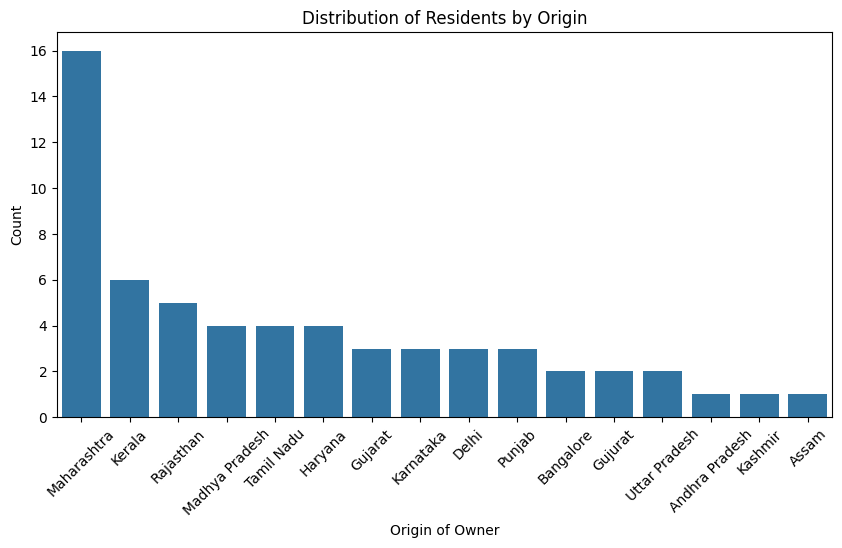

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# Demographic Overview
# Calculate the average number of residents per flat
avg_residents_per_flat = df['No of Resident'].mean()
origin_distribution = df['Origin of Owner'].value_counts()

plt.figure(figsize= (10,5))
sns.barplot(x=origin_distribution.index,y=origin_distribution.values)
plt.title('Distribution of Residents by Origin')
plt.xlabel('Origin of Owner')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

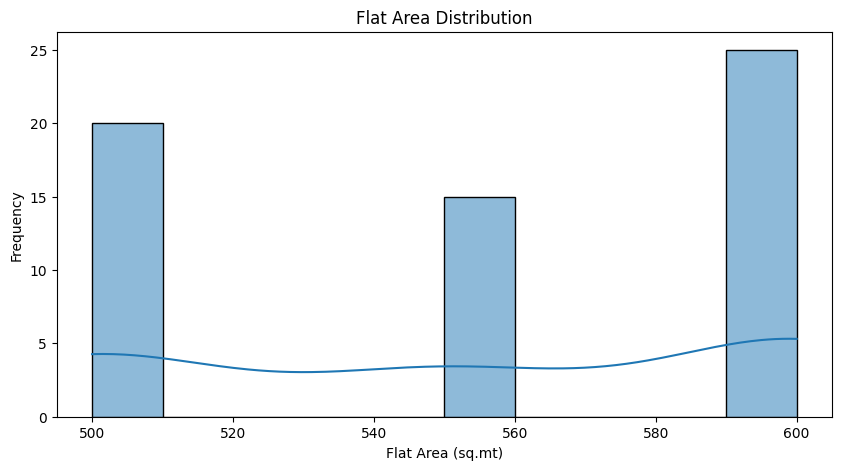

In [ ]:
# Flat Information
# Calculate the average flat area
avg_flat_area = df['Flat Area (sq.mt)'].mean()

most_common_rooms = df['No of Room'].mode().values[0]

plt.figure(figsize= (10,5))
sns.histplot(df['Flat Area (sq.mt)'], bins=10, kde=True)
plt.title('Flat Area Distribution')
plt.xlabel('Flat Area (sq.mt)')
plt.ylabel('Frequency')
plt.show()


Owner     60.0
Tenant    40.0
Name: Tenant or owner, dtype: float64


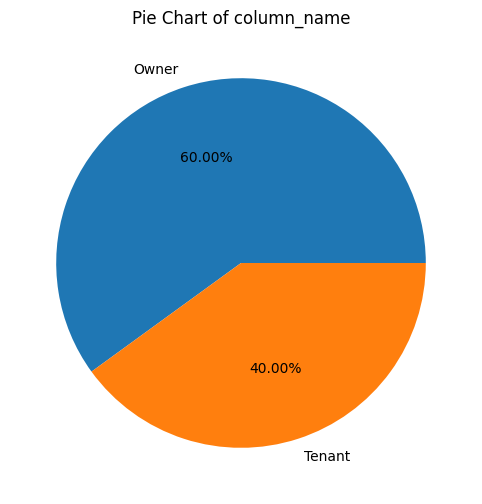

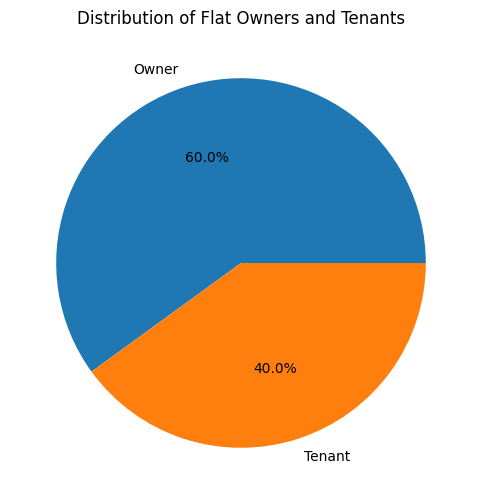

Average Number of Residents per Flat: 554.1666666666666

Average Flat Area: 554.1666666666666 sq.mt

Most Common Number of Rooms in Flats: 2

Percentage of Flat Owners: 60.0 %
Percentage of Tenants: 40.0 %


In [ ]:
print(df['Tenant or owner'].value_counts()/df.shape[0]*100)

plt.figure(figsize= (10,6))
plt.pie(df['Tenant or owner'].value_counts(),labels=df['Tenant or owner'].unique(), autopct='%1.2f%%',)
plt.title('Pie Chart of column_name')
plt.show()

# Owner and Tenant Information
# Calculate the percentage of flat owners and tenants
owner_percentage = (df['Tenant or owner'] == 'Owner').mean() * 100
tenant_percentage = (df['Tenant or owner'] == 'Tenant').mean() * 100

# Visualization: Distribution of Owner vs. Tenant
plt.figure(figsize=(6, 6))
plt.pie([owner_percentage, tenant_percentage], labels=['Owner', 'Tenant'], autopct='%1.1f%%')
plt.title('Distribution of Flat Owners and Tenants')
plt.show()

# Print the calculated statistics
print("Average Number of Residents per Flat:", avg_residents_per_flat)
print("\nAverage Flat Area:", avg_flat_area, "sq.mt")
print("\nMost Common Number of Rooms in Flats:", most_common_rooms)
print("\nPercentage of Flat Owners:", owner_percentage, "%")
print("Percentage of Tenants:", tenant_percentage, "%")

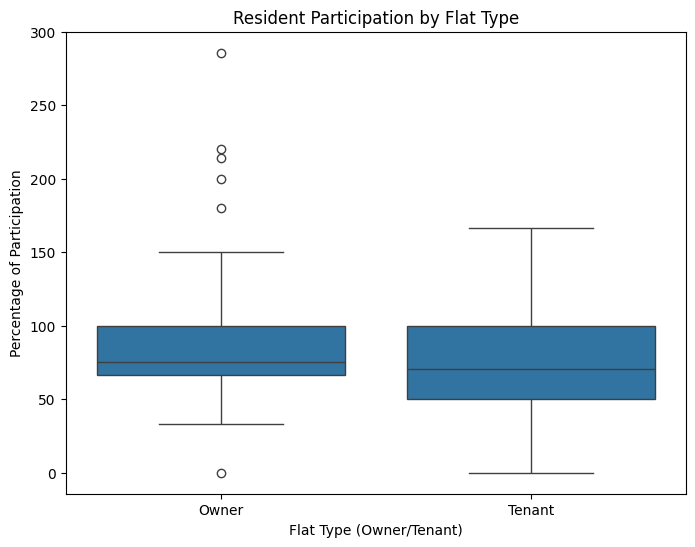

In [ ]:
# print((df['Confirmed Members'] / df['No of Resident']) * 100)
percentage_participation = (df['Confirmed Members'] / df['No of Resident']) * 100
plt.figure(figsize=(8, 6))
sns.boxplot(x='Tenant or owner', y=percentage_participation, data=df)
plt.title('Resident Participation by Flat Type')
plt.xlabel('Flat Type (Owner/Tenant)')
plt.ylabel('Percentage of Participation')
plt.show()

In [ ]:
# Donations Analysis
# Calculate the average donation amount
avg_donation_amount = df['Donation'].mean()
# Calculate the total donation amount collected
total_donation_amount = df['Donation'].sum()

# Event Planning Recommendations
# Recommendations for event planning based on data analysis
recommendations = []
if avg_donation_amount >= 5000:
    recommendations.append("Consider a higher budget for the event.")
else:
    recommendations.append("Budget allocation may be optimized based on donations.")


if percentage_participation.mean() >= 70:
    recommendations.append("Expect a good turnout for the event.")
else:
    recommendations.append("Engage in more outreach to boost participation.")


if total_donation_amount >= 50000:
    recommendations.append("Sufficient funds are available for event planning.")
else:
    recommendations.append("Consider additional fundraising efforts.")

# Print the calculated statistics and recommendations
print("Percentage of Residents' Participation in the Event:")
print(percentage_participation)
print(percentage_participation.mean())
print("\nAverage Donation Amount:", avg_donation_amount)
print("Total Donation Amount Collected:", total_donation_amount)
print("\nEvent Planning Recommendations:")
for recommendation in recommendations:
    print("- " + recommendation)

Percentage of Residents' Participation in the Event:
0     100.000000
1     120.000000
2      60.000000
3      50.000000
4     214.285714
5     100.000000
6     100.000000
7     100.000000
8      40.000000
9      60.000000
10     50.000000
11    285.714286
12    100.000000
13    100.000000
14     75.000000
15     66.666667
16     66.666667
17     50.000000
18     80.000000
19     66.666667
20     75.000000
21     75.000000
22     80.000000
23     75.000000
24     66.666667
25     75.000000
26     60.000000
27     50.000000
28     33.333333
29    100.000000
30    100.000000
31    220.000000
32     75.000000
33     66.666667
34     50.000000
35    100.000000
36     75.000000
37     80.000000
38     66.666667
39    100.000000
40    180.000000
41     80.000000
42     75.000000
43     66.666667
44     50.000000
45     75.000000
46     75.000000
47      0.000000
48      0.000000
49     66.666667
50    100.000000
51     80.000000
52    100.000000
53    166.666667
54    150.000000
55     33.33

In [ ]:
df2

,Unnamed: 0,Plate Cost,Decoration Price,Rating,Caterer Name
0,0,280,5000,2.4,a
1,1,420,4300,3.8,b
2,2,390,5900,3.1,c
3,3,420,6900,4.6,d
4,4,280,6500,2.3,e
5,5,360,7000,3.3,f
6,6,250,4200,3.4,g
7,7,370,4800,3.8,h
8,8,370,5800,3.1,i
9,9,400,6900,2.4,j


In [ ]:
highest_rated_decorator = df2[df2['Rating'] == df2['Rating'].max()]


# Identify the most cost-effective decorator based on decoration price
cost_effective_decorator = df2[df2['Decoration Price'] == df2['Decoration Price'].min()]
print(cost_effective_decorator )

# Caterer Analysis
# Identify the caterer with the highest rating
highest_rated_caterer = df2[df2['Rating'] == df2['Rating'].max()]
# Identify the most cost-effective caterer based on plate cost
cost_effective_caterer = df2[df2['Plate Cost'] == df2['Plate Cost'].min()]
# Caterer and Decorator Recommendations
# Recommendations for selecting the best caterer and decorator
decorator_recommendation = f"The highest-rated decorator is '{highest_rated_decorator['Caterer Name'].values[0]}' with a rating of {highest_rated_decorator['Rating'].values[0]}."
caterer_recommendation = f"The most cost-effective caterer is '{cost_effective_caterer['Caterer Name'].values[0]}' with a plate cost of {cost_effective_caterer['Plate Cost'].values[0]}."
# Print the analysis results and recommendations
print("Decorator Analysis:")
print("Decorator with Highest Rating:")
print(highest_rated_decorator)
print("\nMost Cost-Effective Decorator:")
print(cost_effective_decorator)
print("\nCaterer Analysis:")
print("Caterer with Highest Rating:")
print(highest_rated_caterer)
print("\nMost Cost-Effective Caterer:")
print(cost_effective_caterer)
print("\nCaterer and Decorator Recommendations:")
print(decorator_recommendation)
print(caterer_recommendation)

   Unnamed: 0  Plate Cost  Decoration Price  Rating Caterer Name
6           6         250              4200     3.4            g
Decorator Analysis:
Decorator with Highest Rating:
    Unnamed: 0  Plate Cost  Decoration Price  Rating Caterer Name
15          15         320              5400     4.8            p

Most Cost-Effective Decorator:
   Unnamed: 0  Plate Cost  Decoration Price  Rating Caterer Name
6           6         250              4200     3.4            g

Caterer Analysis:
Caterer with Highest Rating:
    Unnamed: 0  Plate Cost  Decoration Price  Rating Caterer Name
15          15         320              5400     4.8            p

Most Cost-Effective Caterer:
    Unnamed: 0  Plate Cost  Decoration Price  Rating Caterer Name
6            6         250              4200     3.4            g
12          12         250              5000     4.3            m

Caterer and Decorator Recommendations:
The highest-rated decorator is 'p' with a rating of 4.8.
The most cost-effect